TASK 1

In [1]:
!pip install beautifulsoup4 requests

import requests
from bs4 import BeautifulSoup
import pandas as pd

url = "http://books.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

books = soup.find_all("article", class_="product_pod")

data = []
for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    data.append({"Title": title, "Price": price})

df = pd.DataFrame(data)
print(df)

df.to_csv("books_data.csv", index=False)
print("Saved as books_data.csv")

                                                Title    Price
0                                A Light in the Attic  Â£51.77
1                                  Tipping the Velvet  Â£53.74
2                                          Soumission  Â£50.10
3                                       Sharp Objects  Â£47.82
4               Sapiens: A Brief History of Humankind  Â£54.23
5                                     The Requiem Red  Â£22.65
6   The Dirty Little Secrets of Getting Your Dream...  Â£33.34
7   The Coming Woman: A Novel Based on the Life of...  Â£17.93
8   The Boys in the Boat: Nine Americans and Their...  Â£22.60
9                                     The Black Maria  Â£52.15
10     Starving Hearts (Triangular Trade Trilogy, #1)  Â£13.99
11                              Shakespeare's Sonnets  Â£20.66
12                                        Set Me Free  Â£17.46
13  Scott Pilgrim's Precious Little Life (Scott Pi...  Â£52.29
14                          Rip it Up and Start Again  

TASK 2

In [2]:
import pandas as pd

df = pd.read_csv("books_data.csv")
df.head()


,Title,Price
0,A Light in the Attic,Â£51.77
1,Tipping the Velvet,Â£53.74
2,Soumission,Â£50.10
3,Sharp Objects,Â£47.82
4,Sapiens: A Brief History of Humankind,Â£54.23


In [3]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   20 non-null     object
 1   Price   20 non-null     object
dtypes: object(2)
memory usage: 452.0+ bytes


(20, 2)

In [5]:
df["Price"] = df["Price"].str.replace("£", "", regex=False).str.replace("Â", "", regex=False).astype(float)
df.head()

,Title,Price
0,A Light in the Attic,51.77
1,Tipping the Velvet,53.74
2,Soumission,50.10
3,Sharp Objects,47.82
4,Sapiens: A Brief History of Humankind,54.23


In [6]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Title    0
Price    0
dtype: int64
Duplicates: 0


In [7]:
print("Average Price:", df["Price"].mean())
print("Max Price:", df["Price"].max())
print("Min Price:", df["Price"].min())

Average Price: 38.048500000000004
Max Price: 57.25
Min Price: 13.99


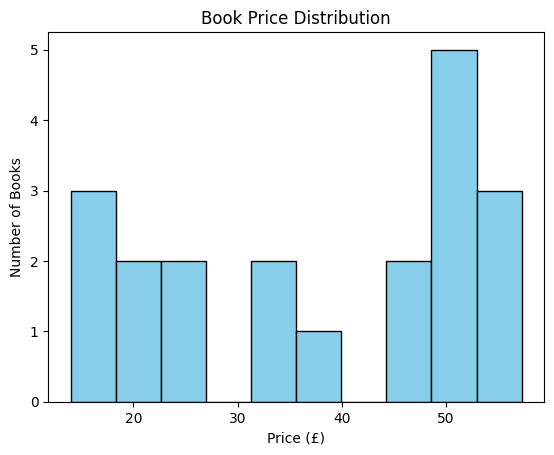

In [8]:
import matplotlib.pyplot as plt

plt.hist(df["Price"], bins=10, color="skyblue", edgecolor="black")
plt.title("Book Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.show()

## EDA Insights
- Dataset has 20 books with no missing values or duplicates
- Average book price is £38.05, ranging from £13.99 to £57.25
- Most books are priced between £45-£55, showing a cluster of premium-priced books
- A smaller group of books fall in the £13-£20 budget range

TASK 3

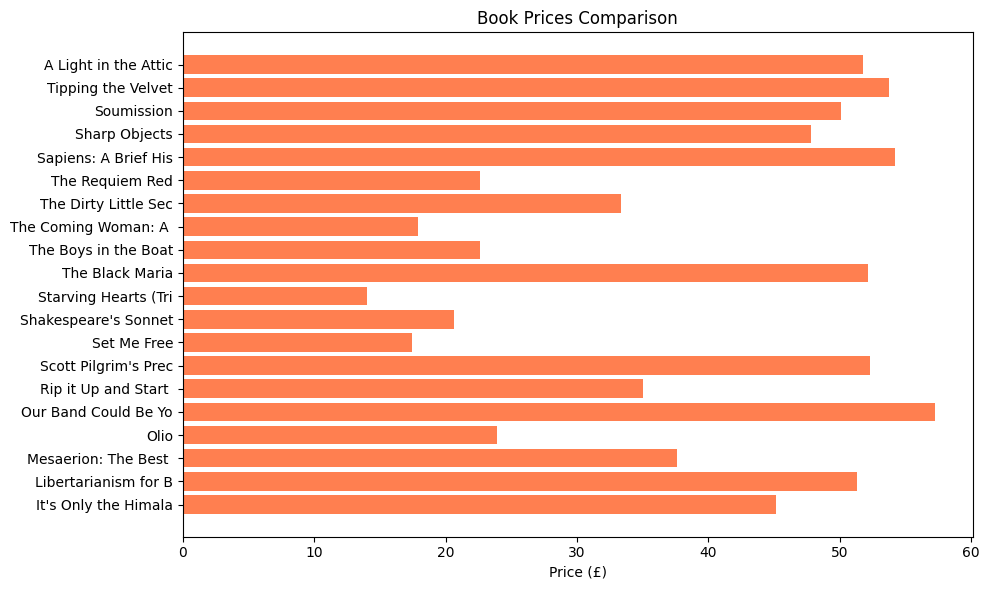

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(df["Title"].str[:20], df["Price"], color="coral")
plt.xlabel("Price (£)")
plt.title("Book Prices Comparison")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

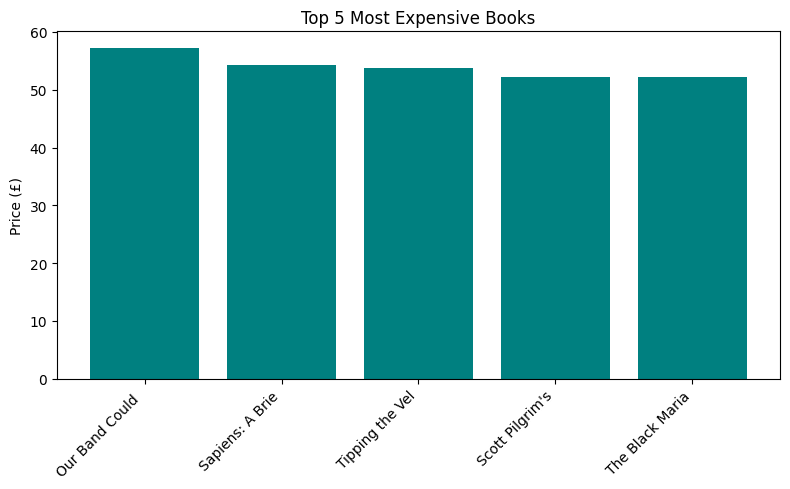

In [10]:
top5 = df.sort_values("Price", ascending=False).head(5)
plt.figure(figsize=(8,5))
plt.bar(top5["Title"].str[:15], top5["Price"], color="teal")
plt.xticks(rotation=45, ha="right")
plt.title("Top 5 Most Expensive Books")
plt.ylabel("Price (£)")
plt.tight_layout()
plt.show()

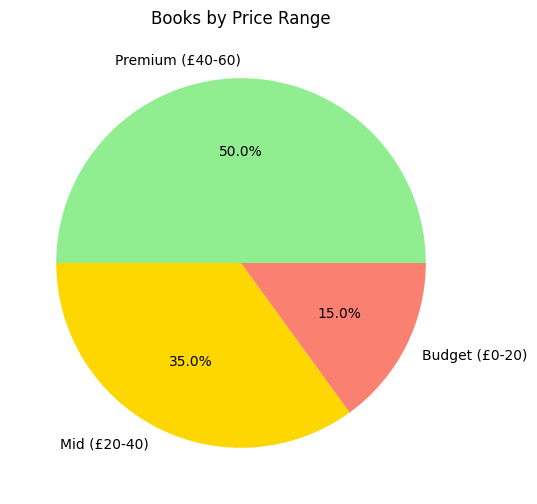

In [11]:
bins = [0, 20, 40, 60]
labels = ["Budget (£0-20)", "Mid (£20-40)", "Premium (£40-60)"]
df["PriceRange"] = pd.cut(df["Price"], bins=bins, labels=labels)

range_counts = df["PriceRange"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(range_counts, labels=range_counts.index, autopct="%1.1f%%", colors=["lightgreen","gold","salmon"])
plt.title("Books by Price Range")
plt.show()

## Visualization Insights
- 50% of books fall in the Premium range (£40-60)
- "Our Band Could Be Your Life" is the most expensive book at £57.25
- Only 15% of books are budget-friendly (under £20)
- Price distribution shows the store leans toward higher-priced titles